In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Создаём папку для графиков, если её нет
FIGURES_DIR = '../reports/figures/01_eda'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Загружаем данные
df = pd.read_csv('../data/raw/cs-training.csv')

In [2]:
pd.set_option('display.width', 300) # Максимальная ширина вывода

# Удаляем столбец-идентификатор перед любыми выводами
df_clean = df.drop('Unnamed: 0', axis=1)

print("Первые 10 строк:")
print(df_clean.head(10))

Первые 10 строк:
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse    DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
0                 1                              0.766127   45                                     2     0.802982         9120.0                               13                        0                             6                                     0                 2.0
1                 0                              0.957151   40                                     0     0.121876         2600.0                                4                        0                             0                                     0                 1.0
2                 0                              0.658180   38                                     1     0.085113         3042.0                              

In [3]:
print("\nИнформация о датасете и типах данных:")
print(df.info())


Информация о датасете и типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  15

In [4]:
pd.set_option('display.width', 300) # Максимальная ширина вывода

print("\nОсновные статистики:")

# Удаляем столбец-идентификатор
df_clean = df.drop('Unnamed: 0', axis=1)

# Теперь описательные статистики будут только по полезным признакам
print(df_clean.describe())


Основные статистики:
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
count     150000.000000                         150000.000000  150000.000000                         150000.000000  150000.000000   1.202690e+05                    150000.000000            150000.000000                 150000.000000                         150000.000000       146076.000000
mean           0.066840                              6.048438      52.295207                              0.421033     353.005076   6.670221e+03                         8.452760                 0.265973                      1.018240                              0.240387            0.757222
std            0.249746                            249.755371      14.771866                             

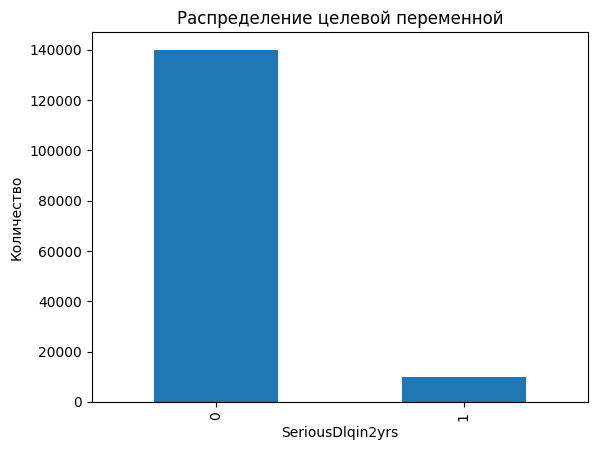

In [5]:
# График баланса классов
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Количество')
plt.savefig(os.path.join(FIGURES_DIR, 'class_balance.png'), bbox_inches='tight')
plt.show()

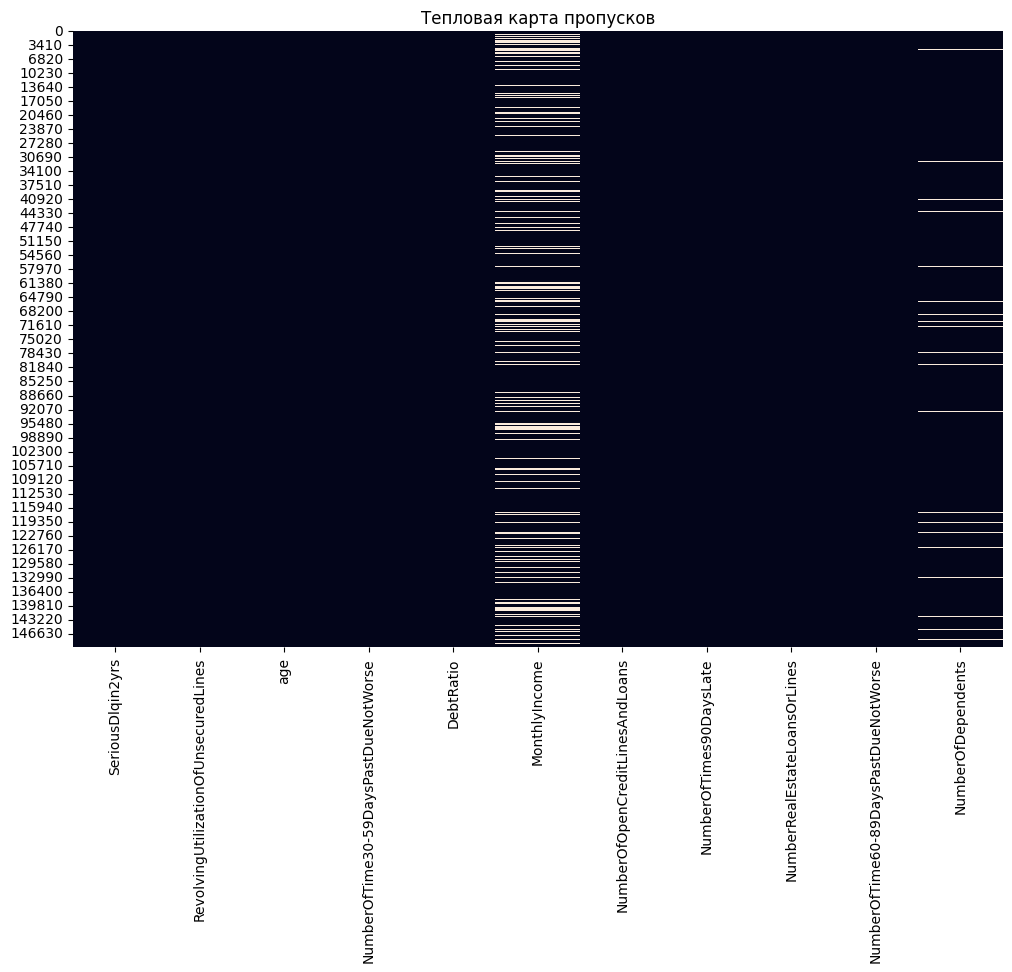

In [6]:
# Тепловая карта пропусков (без Unnamed: 0)
df_clean = df.drop('Unnamed: 0', axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.isnull(), cbar=False)
plt.title('Тепловая карта пропусков')
plt.savefig(os.path.join(FIGURES_DIR, 'missing_heatmap.png'), bbox_inches='tight')
plt.show()

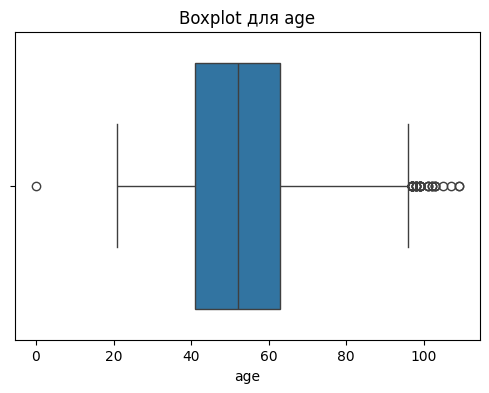

Нижняя теоретическая граница: 8.00
Верхняя теоретическая граница: 96.00
Значение нижнего уса: 21
Значение верхнего уса: 96


In [7]:
# Boxplot для возраста
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title('Boxplot для age')
plt.savefig(os.path.join(FIGURES_DIR, 'boxplot_age.png'), bbox_inches='tight')
plt.show()

# Рассчет границ "усов"
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# Теоретические границы для "усов"
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Реальные значения, на которых заканчиваются "усы"
whisker_low = df[df['age'] >= lower_bound]['age'].min()
whisker_high = df[df['age'] <= upper_bound]['age'].max()

print(f"Нижняя теоретическая граница: {lower_bound:.2f}")
print(f"Верхняя теоретическая граница: {upper_bound:.2f}")
print(f"Значение нижнего уса: {whisker_low}")
print(f"Значение верхнего уса: {whisker_high}")

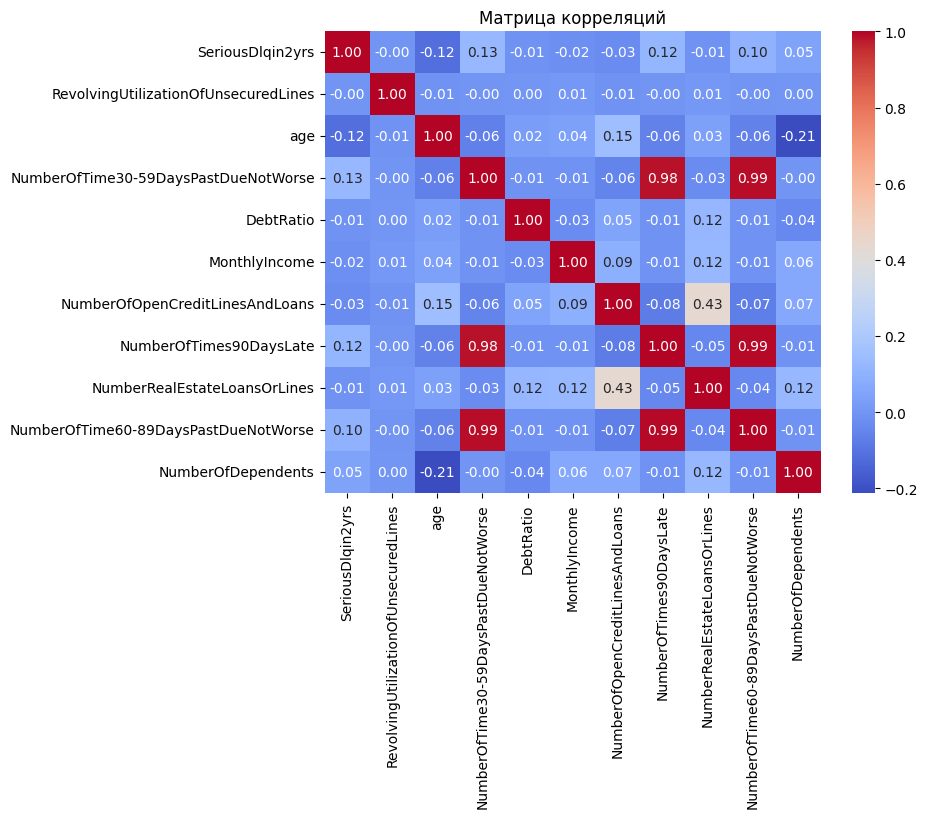

In [8]:
# Корреляционная матрица (без Unnamed: 0)

plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('Unnamed: 0', axis=1).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций')
plt.savefig(os.path.join(FIGURES_DIR, 'corr_heatmap.png'), bbox_inches='tight')

plt.show()